 <font size="10">**Notebook 02: Ambient RNA investigation: part 3**</font>
***

<div class="alert alert-info">
    
<b> <h1> ℹ️ <strong> <font size="6" color="black"> Important notebook information </font> </strong> </h1> </b>
    <hr>
    <font size="4" color="black">
        The purpose of this notebook is to  investigate the amount of ambient RNA contribution / "soup" for each donor<br> <br>
        As this is running Cellbender it is trying to account for free floating mRNA which is captured during droplet encapsulation and barcode swapping during PCR cycling
    </font>

# investigate soup contribution per embryo

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
metadata_obj = sc.read('/nfs/team298/ar32/Whole_embryo/pan_fetal_LR/working_data_2.h5ad')

# Create a soup matrix for each embryo

## Embryo 1

In [ ]:
Embryo1 = sc.read('/home/jovyan/mounting_point/Newcastle_1TB/newcastle/AntonyRose/Embryo_objects/Cellranger_raw_with_background/'+ 'Embryo1_all_lanes_raw_counts_20220126.h5ad')
Embryo1_cellbender = sc.read('/home/jovyan/mounting_point/Newcastle_1TB/newcastle/AntonyRose/Embryo_objects/Cellbender_Embryo1_all_lanes_passed_cellranger_raw_counts_20220121.h5ad')
Embryo1 = Embryo1[Embryo1.obs.index.isin(list(Embryo1_cellbender.obs.index))]
Embryo1_cellbender = Embryo1_cellbender[Embryo1_cellbender.obs.index.isin(list(Embryo1.obs.index))]
Embryo1 = Embryo1[Embryo1_cellbender.obs_names, :]
Embryo1.layers['soup'] = Embryo1.X - Embryo1_cellbender.X

In [ ]:
Embryo1.write('/home/jovyan/mount_farm/nfs/team298/ar32/Whole_embryo/random_temp_storage/Embryo1_object_looking_at_soup_20220223.h5ad')

## Embryo 2

In [ ]:
Embryo2 = sc.read('/home/jovyan/mounting_point/Newcastle_1TB/newcastle/AntonyRose/Embryo_objects/Cellranger_raw_with_background/'+ 'Embryo2_all_lanes_raw_counts_20220126.h5ad')
Embryo2_cellbender = sc.read('/home/jovyan/mounting_point/Newcastle_1TB/newcastle/AntonyRose/Embryo_objects/Cellbender_Embryo2_all_lanes_passed_cellranger_raw_counts_20220121.h5ad')
Embryo2 = Embryo2[Embryo2.obs.index.isin(list(Embryo2_cellbender.obs.index))]
Embryo2_cellbender = Embryo2_cellbender[Embryo2_cellbender.obs.index.isin(list(Embryo2.obs.index))]
Embryo2 = Embryo2[Embryo2_cellbender.obs_names, :]
Embryo2.layers['soup'] = Embryo2.X - Embryo2_cellbender.X

In [ ]:
Embryo2.write('/home/jovyan/mount_farm/nfs/team298/ar32/Whole_embryo/random_temp_storage/Embryo2_object_looking_at_soup_20220223.h5ad')

# Embryo 3

In [ ]:
Embryo3 = sc.read('/nfs/team298/ar32/Whole_embryo/Cell_ranger_outs/Cellranger_comparison_generated_matrix_F138_20220801.h5ad')
Embryo3_cellbender = sc.read('/nfs/team298/ar32/Whole_embryo/Cell_bender_outs/F158/Cellbender_generated_matrix_20220801.h5ad')

In [ ]:
Embryo3 = Embryo3[Embryo3.obs.index.isin(list(Embryo3_cellbender.obs.index))]
Embryo3_cellbender = Embryo3_cellbender[Embryo3_cellbender.obs.index.isin(list(Embryo3.obs.index))]
Embryo3 = Embryo3[Embryo3_cellbender.obs_names, :]
Embryo3.layers['soup'] = Embryo3.X - Embryo3_cellbender.X

In [ ]:
Embryo3.write('/nfs/team298/ar32/Whole_embryo/Cell_bender_outs/F158/Embryo3_object_looking_at_soup_20220801.h5ad')

# Add metadata

In [ ]:
Embryo1.obs['total_soup'] = np.array(Embryo1.layers['soup'].sum(1)).flatten()
Embryo1.obs['total_RNA_with_soup'] = np.array(Embryo1.X.sum(1)).flatten()
Embryo1.obs['total_RNA_without_soup'] = np.array(Embryo1_cellbender.X.sum(1)).flatten()
Embryo2.obs['total_soup'] = np.array(Embryo2.layers['soup'].sum(1)).flatten()
Embryo2.obs['total_RNA_with_soup'] = np.array(Embryo2.X.sum(1)).flatten()
Embryo2.obs['total_RNA_without_soup'] = np.array(Embryo2_cellbender.X.sum(1)).flatten()
Embryo3.obs['total_soup'] = np.array(Embryo3.layers['soup'].sum(1)).flatten()
Embryo3.obs['total_RNA_with_soup'] = np.array(Embryo3.X.sum(1)).flatten()
Embryo3.obs['total_RNA_without_soup'] = np.array(Embryo3_cellbender.X.sum(1)).flatten()

In [ ]:
sc.pp.calculate_qc_metrics(Embryo1, inplace=True)

In [ ]:
sc.pp.calculate_qc_metrics(Embryo2, inplace=True)

In [ ]:
sc.pp.calculate_qc_metrics(Embryo3, inplace=True)

In [ ]:
Embryo1.obs['nCounts'] = np.log10(Embryo1.obs['total_counts'].values)
Embryo2.obs['nCounts'] = np.log10(Embryo2.obs['total_counts'].values)
Embryo3.obs['nCounts'] = np.log10(Embryo3.obs['total_counts'].values)

In [ ]:
metadata1 = metadata_obj[metadata_obj.obs.index.isin(list(Embryo1.obs.index))]
metadata2 = metadata_obj[metadata_obj.obs.index.isin(list(Embryo2.obs.index))]
metadata3 = metadata_obj[metadata_obj.obs.index.isin(list(Embryo3.obs.index))]

Embryo1 = Embryo1[Embryo1.obs.index.isin(list(metadata1.obs.index)),:]
Embryo2 = Embryo2[Embryo2.obs.index.isin(list(metadata2.obs.index)),:]
Embryo3 = Embryo3[Embryo3.obs.index.isin(list(metadata3.obs.index)),:]

E1_meta = pd.DataFrame()
E2_meta = pd.DataFrame()
E3_meta = pd.DataFrame()

cols = [
'dataset', 'sequencing_lane_ID', 'haniffa_ID', 'HDBR_ID',
'sequencing_type', '10x_kit', 'spatial_location',
'spatial_location_replicates', 'sort_ID', 'procedure', 'age_in_cs',
'sex', 'alignment_software', 'alignment_reference',
'cutoff_1.4826_is_doublet', 'cutoff_2_is_doublet',
'cutoff_3_is_doublet', 'nUMI', 'nGene', 'nCounts', 'percent.mito',
'percent.ribo',
'neighbours_15_leiden_res_0_5', 'neighbours_15_leiden_res_3',
'neighbours_20_leiden_res_0_5', 'neighbours_20_leiden_res_3',
'neighbours_25_leiden_res_0_5', 'neighbours_25_leiden_res_3',
'neighbours_30_leiden_res_0_5', 'neighbours_30_leiden_res_3',
'individual_predictions',
'neighbours_30_leiden_res_3_basic_freq_redist',
'individual_predictions_high_conf',
'neighbours_30_leiden_res_3_basic_freq_redist_high_conf_labels',
'neighbours_30_leiden_res_3_over_clust_res_1',
'neighbours_30_leiden_res_3_over_clust_res_30',
'neighbours_30_leiden_res_3_over_clust_res_1_basic_freq_redist_high_conf_labels',
'neighbours_30_leiden_res_3_over_clust_res_30_basic_freq_redist_high_conf_labels',
'working_broad']

E1_meta[cols] = metadata1.obs[cols]
E2_meta[cols] = metadata2.obs[cols]
E3_meta[cols] = metadata3.obs[cols]

# Investigate soup contribution

### Embryo 1

/home/jovyan/my-conda-envs/Python_env_Hlab/lib/python3.9/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


------------------------------------------------------------------------------------------------------------------------------------------------------ 



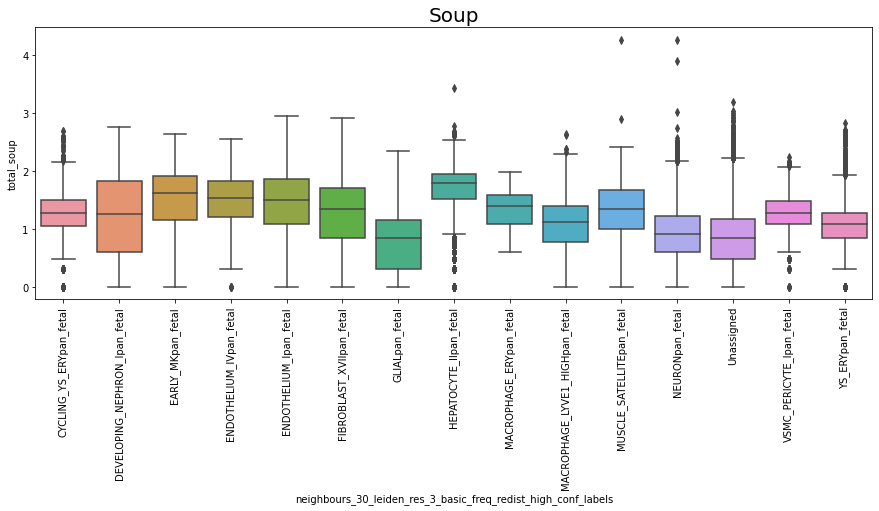

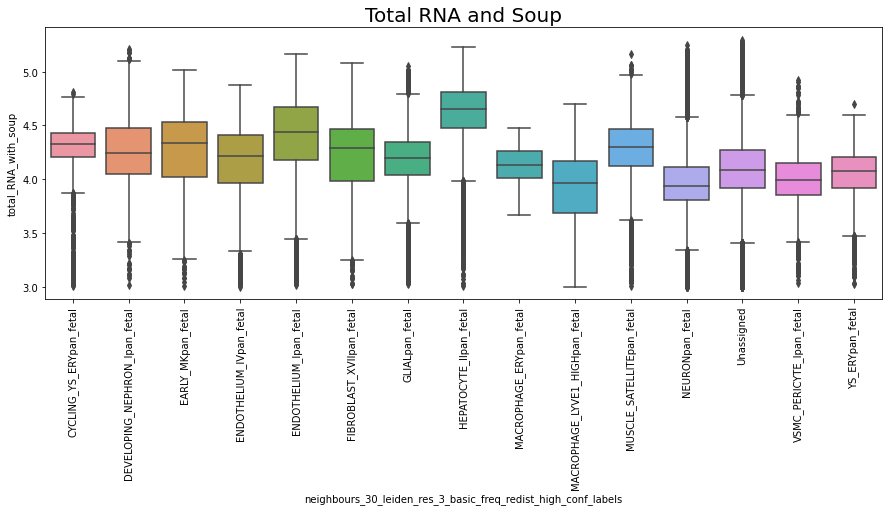


------------------------------------------------------------------------------------------------------------------------------------------------------ 



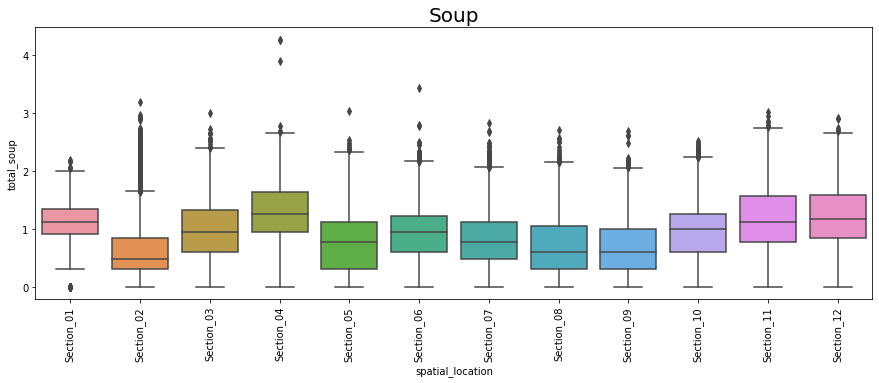

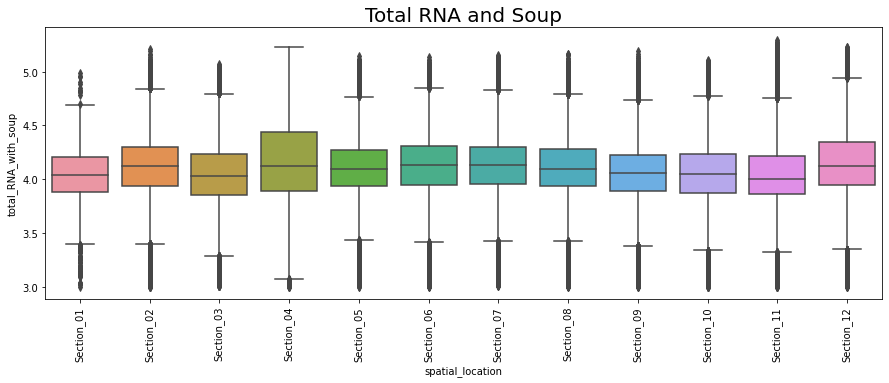


------------------------------------------------------------------------------------------------------------------------------------------------------ 



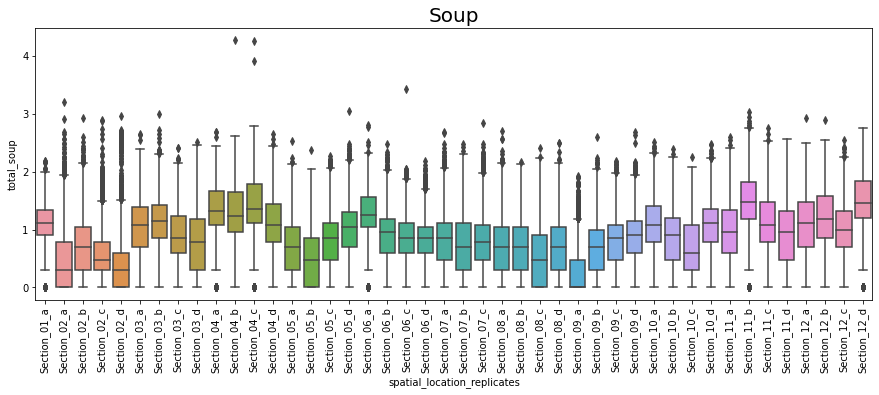

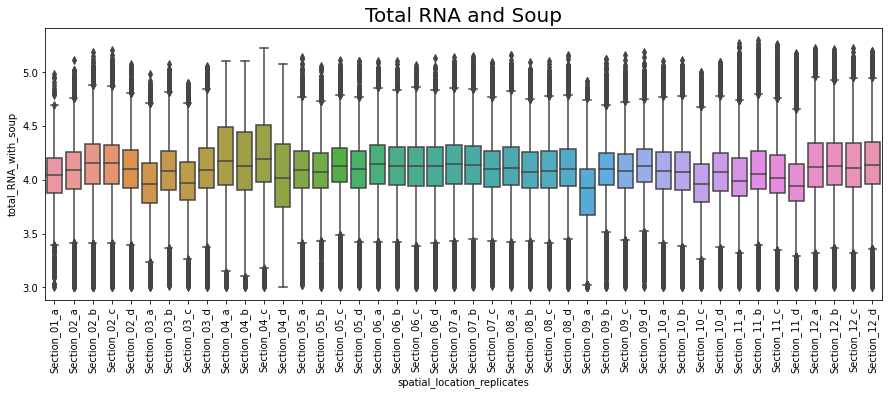


------------------------------------------------------------------------------------------------------------------------------------------------------ 



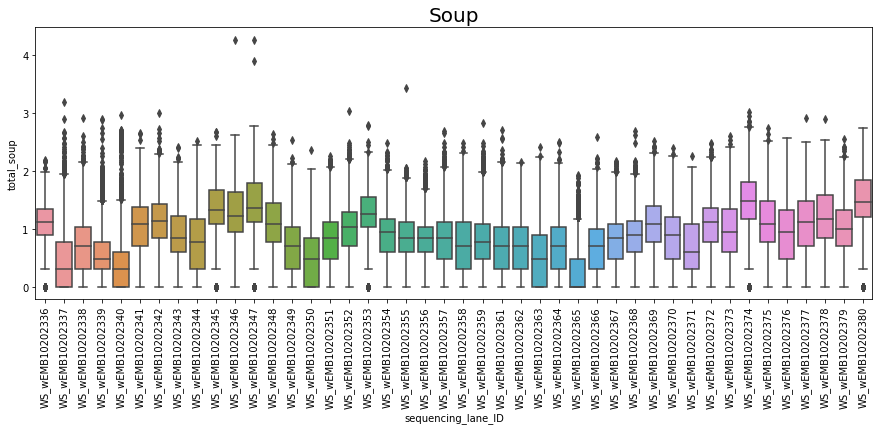

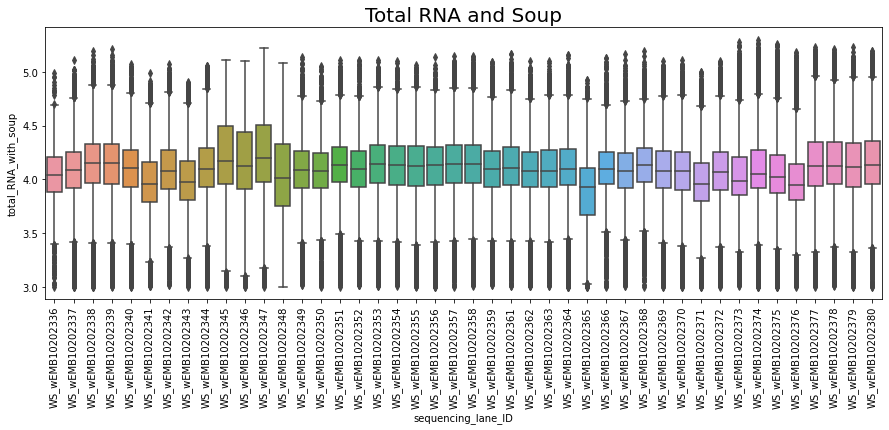

In [ ]:
obs = E1_meta[:]
data = Embryo1
obs = obs[obs.index.isin(list(data.obs.index))]
obs['total_soup'] = np.log10(data.obs['total_soup'][obs.index])
obs['total_RNA_with_soup'] = np.log10(data.obs['total_RNA_with_soup'][obs.index])

meta = E1_meta

print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='neighbours_30_leiden_res_3_basic_freq_redist_high_conf_labels', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='neighbours_30_leiden_res_3_basic_freq_redist_high_conf_labels', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")
print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")
print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location_replicates', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location_replicates', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")
print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='sequencing_lane_ID', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='sequencing_lane_ID', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")

In [ ]:
gene_data =  pd.DataFrame(data.layers['soup'].todense())
gene_data.index = data.obs.index
gene_data.columns = data.var.index

## Exploration

## Effect on overall data

In [ ]:
sorted_df = gene_data.sum().sort_values(ascending=False)
print('Top 200 genes contributing to soup overall in data:')
sorted_df[:200]

Top 200 genes contributing to soup overall in data:


EEF1A1       478036.0
MT-CO1       288656.0
RPL41        189019.0
ACTB         187557.0
MT-CO2       171510.0
MT-CO3       171453.0
RPLP1        159738.0
RPL10        152299.0
MALAT1       124465.0
ACTG1        106347.0
RPS8          96069.0
GAPDH         79581.0
VIM           76136.0
RPL13         74811.0
HBZ           69999.0
RPS12         63024.0
HBE1          60196.0
RPL32         58544.0
RPLP0         54305.0
RPS23         52908.0
RPS3          52280.0
RPS15A        50922.0
MT-ND4L       50254.0
FTL           48957.0
MT-CYB        48873.0
RPS3A         48592.0
RPL7A         47795.0
RPS4X         46262.0
SERPINA1      45880.0
RPS14         42535.0
APOA2         41873.0
RPS19         39833.0
RPL18A        39621.0
RPL30         35985.0
RPS13         35258.0
RPL28         34141.0
APOA1         32895.0
PTMA          30474.0
AFP           30309.0
TMSB10        30303.0
HIST1H4C      30299.0
RPL29         29688.0
RPS24         28660.0
RPS18         28350.0
RPL11         27646.0
TUBB      

## Effect in column of interest
- e.g. Section
- e.g. Section repliacte

### Section 5 example

In [ ]:
met_sub = meta[meta['spatial_location'].isin(['Section_05'])]
top_20 = (list((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False).index))[0:20]
display(gene_data.loc[gene_data.index.isin(met_sub.index)][top_20])
print("")
print("Top number of genes based off restriction applied:")
display((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False)[:20])

,EEF1A1,MT-CO1,MALAT1,RPL41,RPL10,RPLP1,ACTB,MT-CO3,MT-CO2,RPS8,HBZ,ACTG1,HBE1,RPS12,RPL13,RPL32,ACTC1,RPS4X,GAPDH,MT1E
GCTGGGTAGGACGAAA-WS_wEMB10202349,5.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
CAAGATCTCGACAGCC-WS_wEMB10202349,6.0,4.0,3.0,3.0,3.0,2.0,2.0,3.0,2.0,2.0,1.0,2.0,0.0,2.0,2.0,2.0,12.0,2.0,2.0,0.0
GTACTTTGTTCAGACT-WS_wEMB10202349,6.0,4.0,3.0,3.0,3.0,2.0,2.0,3.0,2.0,2.0,0.0,2.0,0.0,2.0,2.0,2.0,5.0,2.0,2.0,0.0
TGAGAGGCAGTAAGAT-WS_wEMB10202349,6.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,0.0,2.0,1.0,1.0,2.0,1.0,1.0,0.0
ACGGCCACACACGCTG-WS_wEMB10202349,5.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTGTTAGGTCGCTTTC-WS_wEMB10202352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCAGCAATCGGGAGTA-WS_wEMB10202352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CTTCTCTCATAGAAAC-WS_wEMB10202352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCTTTCTCACGGCGTT-WS_wEMB10202352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top number of genes based off restriction applied:


EEF1A1    38055.0
MT-CO1    16975.0
MALAT1    13143.0
RPL41     12321.0
RPL10     11599.0
RPLP1     10323.0
ACTB      10094.0
MT-CO3     7851.0
MT-CO2     7354.0
RPS8       6239.0
HBZ        5532.0
ACTG1      5525.0
HBE1       5149.0
RPS12      3365.0
RPL13      3354.0
RPL32      3128.0
ACTC1      3112.0
RPS4X      3108.0
GAPDH      3038.0
MT1E       2867.0
dtype: float32

### Section 3_b

In [ ]:
met_sub = meta[meta['spatial_location_replicates'].isin(['Section_03_b'])]
top_20 = (list((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False).index))[0:20]
display(gene_data.loc[gene_data.index.isin(met_sub.index)][top_20])
print("")
print("Top number of genes based off restriction applied:")
display((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False)[:20])

,MT-CO1,MT-CO3,MT-CO2,EEF1A1,MT-ND4L,MT-CYB,RPL41,RPLP1,RPL10,ACTB,MT-ND3,RPS8,MALAT1,RPS12,ACTG1,RPL13,RPL32,TUBB3,MT-ATP6,MT-ND1
GCATGCGCATTGGCGC-WS_wEMB10202342,9.0,8.0,7.0,6.0,4.0,4.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0
ATTCTACGTGCACCAC-WS_wEMB10202342,9.0,8.0,7.0,6.0,4.0,4.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0
GCGCAACAGAGTCGGT-WS_wEMB10202342,10.0,8.0,7.0,6.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0
ACTGAACAGACATAAC-WS_wEMB10202342,10.0,8.0,7.0,7.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0
TTAACTCTCGCCAAAT-WS_wEMB10202342,9.0,7.0,7.0,6.0,4.0,4.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GACGTGCGTACCGCTG-WS_wEMB10202342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCTATTAAGTCCATAC-WS_wEMB10202342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGCGAGCAGCTGCTG-WS_wEMB10202342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ATTTCTGAGCGTAGTG-WS_wEMB10202342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top number of genes based off restriction applied:


MT-CO1     27655.0
MT-CO3     21533.0
MT-CO2     19466.0
EEF1A1     16669.0
MT-ND4L     9843.0
MT-CYB      9120.0
RPL41       7513.0
RPLP1       6268.0
RPL10       6237.0
ACTB        6154.0
MT-ND3      4504.0
RPS8        4186.0
MALAT1      3914.0
RPS12       2950.0
ACTG1       2815.0
RPL13       2738.0
RPL32       2710.0
TUBB3       2693.0
MT-ATP6     2524.0
MT-ND1      2384.0
dtype: float32

### Celltype: NEURON from working_broad

In [ ]:
met_sub = meta[meta['working_broad'].isin(['NEURON'])]
top_20 = (list((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False).index))[0:20]
display(gene_data.loc[gene_data.index.isin(met_sub.index)][top_20])
print("")
print("Top number of genes based off restriction applied:")
display((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False)[:20])

,EEF1A1,MT-CO1,ACTB,RPL41,RPLP1,RPL10,ACTG1,MT-CO3,VIM,MALAT1,MT-CO2,GAPDH,RPS8,RPL13,HIST1H4C,HBZ,RPLP0,RPL32,RPS12,RPS23
AGAGCTTAGGCCATAG-WS_wEMB10202336,6.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,1.0,3.0,2.0,2.0,2.0,2.0,1.0,0.0,2.0,2.0,2.0,2.0
ATGAGGGGTATATCCG-WS_wEMB10202336,6.0,2.0,3.0,3.0,3.0,3.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,0.0,2.0,2.0,2.0,2.0
TGCACCTTCCCGACTT-WS_wEMB10202336,4.0,2.0,2.0,3.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0
ATCATCTAGCTAGTGG-WS_wEMB10202336,5.0,2.0,3.0,3.0,3.0,3.0,2.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,0.0,0.0,2.0,2.0,2.0,2.0
ACGATGTGTTCGTTGA-WS_wEMB10202336,5.0,2.0,3.0,3.0,3.0,3.0,2.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,0.0,0.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTAACGTTCGAATGCT-WS_wEMB10202380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAGTCTGAGAGTAAGG-WS_wEMB10202380,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
ACTGAACAGTCAATAG-WS_wEMB10202380,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ATCTACTCAGACGCCT-WS_wEMB10202380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top number of genes based off restriction applied:


EEF1A1      149506.0
MT-CO1       64336.0
ACTB         63162.0
RPL41        56090.0
RPLP1        46737.0
RPL10        44471.0
ACTG1        40051.0
MT-CO3       37581.0
VIM          34509.0
MALAT1       32100.0
MT-CO2       31833.0
GAPDH        31216.0
RPS8         28111.0
RPL13        24381.0
HIST1H4C     22318.0
HBZ          19375.0
RPLP0        19227.0
RPL32        18889.0
RPS12        18491.0
RPS23        18215.0
dtype: float32

# Scatterplots

### Cells containing the most soup

In [ ]:
data.obs[cols] = meta[cols]

Trying to set attribute `.obs` of view, copying.


Text(0.5, 1.0, 'Soup')

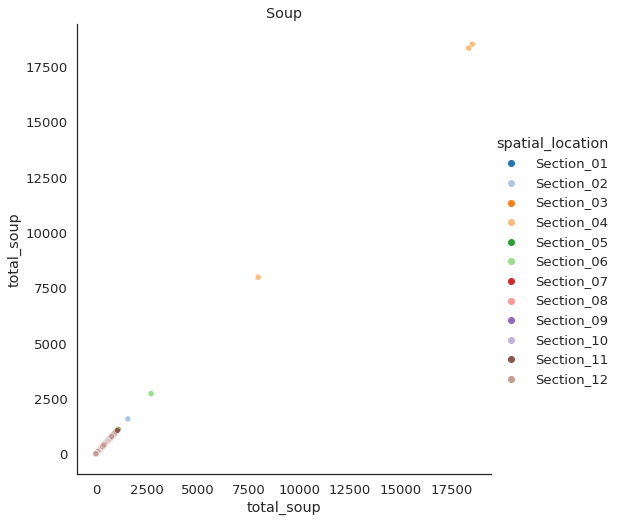

In [ ]:
# Check which sections contain cells with the most soup
sns.set(font_scale = 1.2)
sns.set_style("white")
sns.relplot(data=data.obs, x='total_soup', y='total_soup', hue='spatial_location', height=7, legend="full", palette='tab20')
plt.title('Soup')

Text(0.5, 1.0, 'Soup')

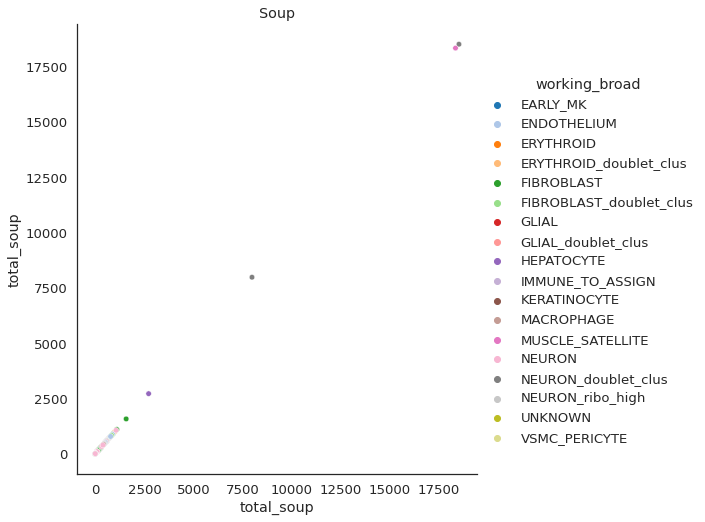

In [ ]:
# Check which celltypes contain most soup
data_plot = data.obs
sns.set(font_scale = 1.2)
sns.set_style("white")
sns.relplot(data=data_plot, x='total_soup', y='total_soup', hue='working_broad', height=7, legend="full", palette='tab20', s=30,)
plt.title('Soup')

### Embryo 2

/home/jovyan/my-conda-envs/Python_env_Hlab/lib/python3.9/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


------------------------------------------------------------------------------------------------------------------------------------------------------ 



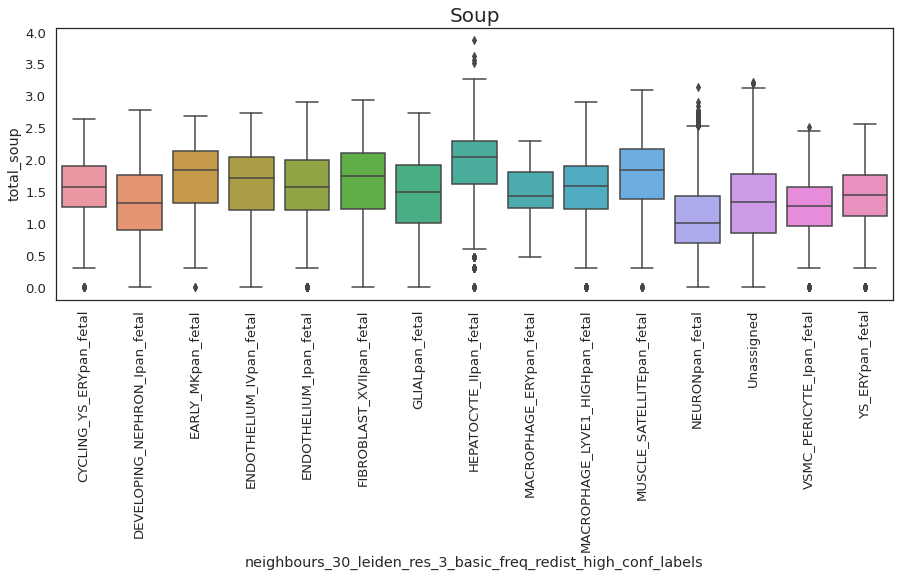

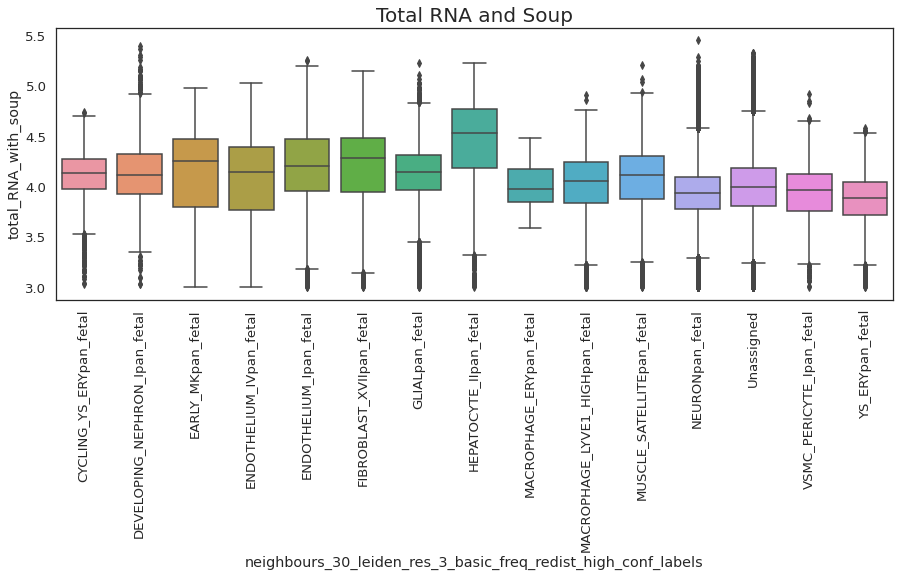


------------------------------------------------------------------------------------------------------------------------------------------------------ 



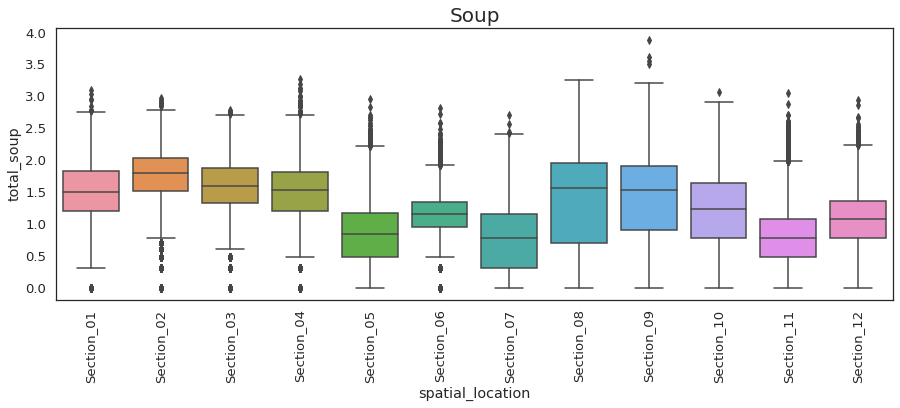

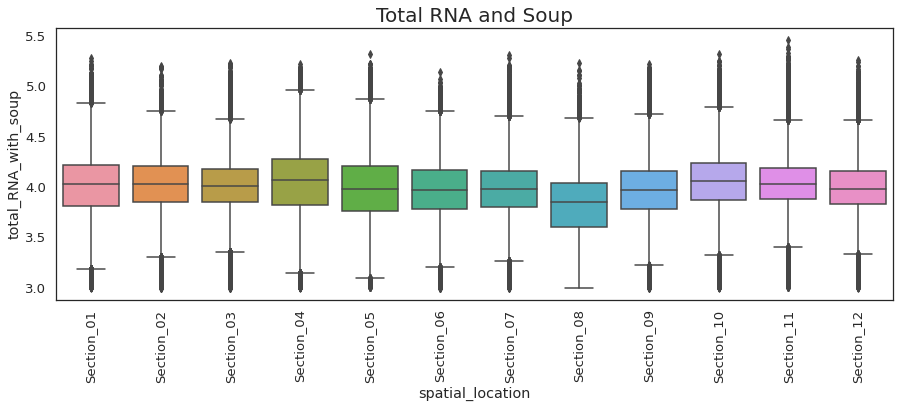


------------------------------------------------------------------------------------------------------------------------------------------------------ 



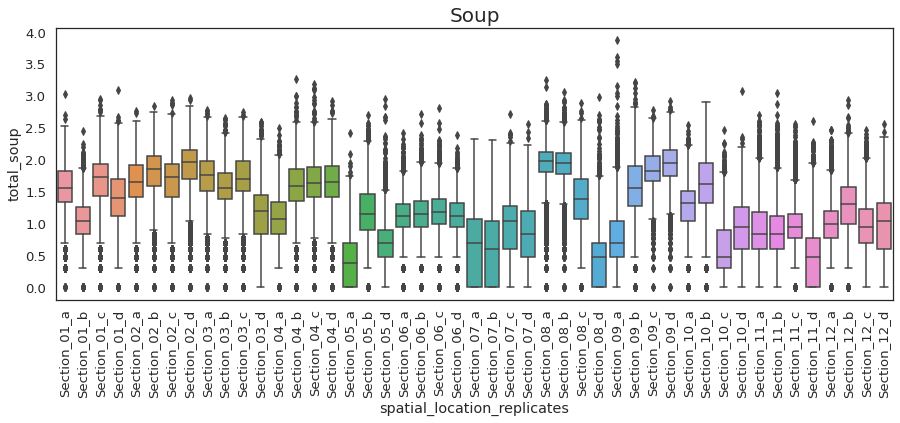

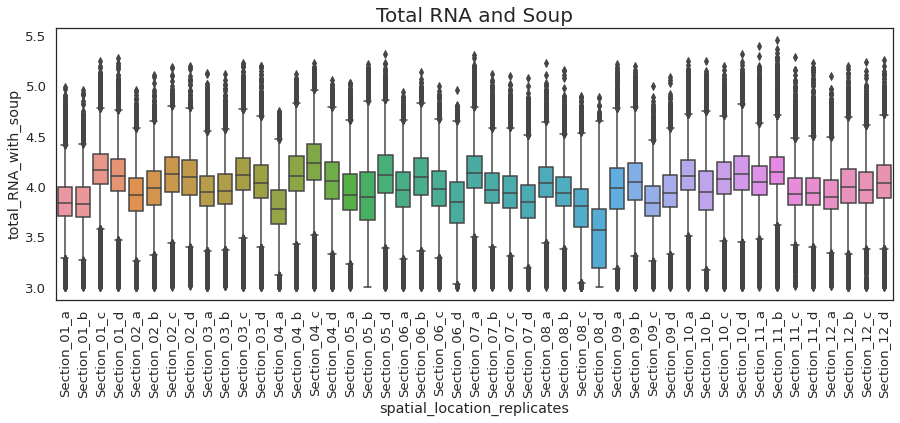


------------------------------------------------------------------------------------------------------------------------------------------------------ 



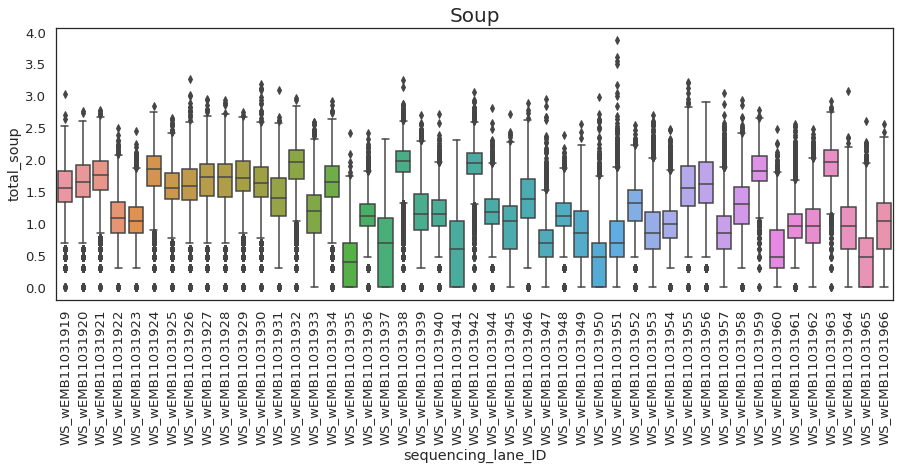

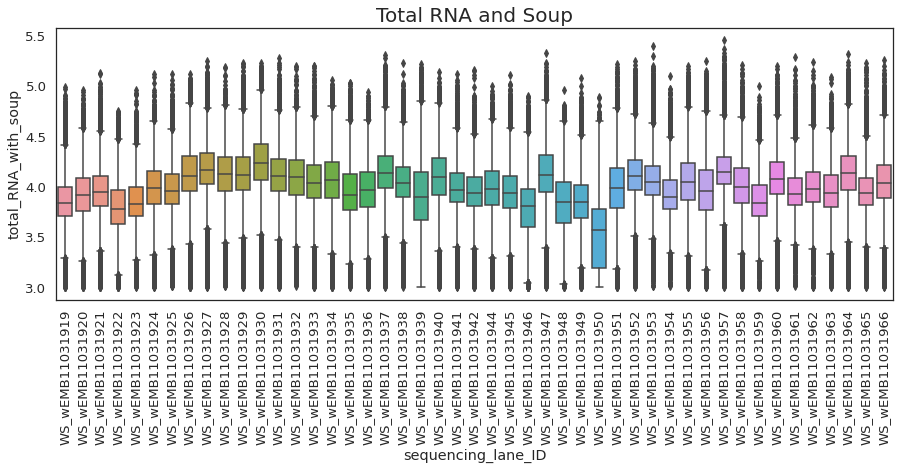

In [ ]:
obs = E2_meta[:]
data = Embryo2
obs = obs[obs.index.isin(list(data.obs.index))]
obs['total_soup'] = np.log10(data.obs['total_soup'][obs.index])
obs['total_RNA_with_soup'] = np.log10(data.obs['total_RNA_with_soup'][obs.index])

meta = E2_meta

print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='neighbours_30_leiden_res_3_basic_freq_redist_high_conf_labels', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='neighbours_30_leiden_res_3_basic_freq_redist_high_conf_labels', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")
print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")
print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location_replicates', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location_replicates', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")
print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='sequencing_lane_ID', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='sequencing_lane_ID', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")

In [ ]:
gene_data =  pd.DataFrame(data.layers['soup'].todense())
gene_data.index = data.obs.index
gene_data.columns = data.var.index

## Exploration

## Effect on overall data

In [ ]:
sorted_df = gene_data.sum().sort_values(ascending=False)
print('Top 200 genes contributing to soup overall in data:')
sorted_df[:200]

Top 200 genes contributing to soup overall in data:


MT-CO1       1611851.0
MTRNR2L12    1176507.0
MT-CO3        805080.0
EEF1A1        743526.0
MT-ATP6       611444.0
MT-CO2        526302.0
MT-CYB        446974.0
ACTB          415920.0
RPL41         403357.0
RPLP1         399675.0
MALAT1        392627.0
ACTG1         382387.0
RPL10         376987.0
RPS8          354947.0
RPL13         263650.0
RPS12         239495.0
RPL32         211995.0
RPS3A         206471.0
RPS18         204944.0
RPS23         202232.0
RPS19         181389.0
GAPDH         170114.0
MT-ND4L       166402.0
RPS14         161065.0
RPLP0         156578.0
RPL18A        153957.0
MT-ND4        150799.0
RPS15A        150205.0
VIM           148633.0
RPL28         147915.0
PTMA          146400.0
RPL7A         141526.0
RPS3          140250.0
TPT1          139949.0
RPL30         138338.0
RPS13         133578.0
RPL11         130469.0
RPL19         123456.0
RPS24         121792.0
MT-ND1        121716.0
RPS2          121218.0
MT-ND5        121058.0
RPL6          111187.0
RPL3       

## Effect in column of interest
- e.g. Section
- e.g. Section repliacte

### Section 5 example

In [ ]:
met_sub = meta[meta['spatial_location'].isin(['Section_05'])]
top_20 = (list((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False).index))[0:20]
display(gene_data.loc[gene_data.index.isin(met_sub.index)][top_20])
print("")
print("Top number of genes based off restriction applied:")
display((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False)[:20])

,MTRNR2L12,MT-CO1,MT-ATP6,EEF1A1,MT-CO3,MT-CO2,MT-CYB,ACTG1,RPL10,ACTB,RPLP1,RPL41,RPS8,MALAT1,RPL13,SERPINA1,MT-ND4,RPS12,AFP,APOA2
CGATTGAAGACTGTAA-WS_wEMB11031935,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
TTCTTAGCAGCTGTTA-WS_wEMB11031935,2.0,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
GTCACAAAGGCAGGTT-WS_wEMB11031935,4.0,5.0,2.0,3.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,1.0,1.0,1.0,0.0
AACTCTTCATTACCTT-WS_wEMB11031935,2.0,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
CACACAACATTTCACT-WS_wEMB11031935,2.0,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTGCTTCGTAGGACAC-WS_wEMB11031947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CTCTACGTCAGGCGAA-WS_wEMB11031947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCATTCGTCCTAGAAC-WS_wEMB11031947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CGATTGACACAAGACG-WS_wEMB11031947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top number of genes based off restriction applied:


MTRNR2L12    53354.0
MT-CO1       44801.0
MT-ATP6      15418.0
EEF1A1       15151.0
MT-CO3       14579.0
MT-CO2        9416.0
MT-CYB        7612.0
ACTG1         6061.0
RPL10         5812.0
ACTB          5437.0
RPLP1         5393.0
RPL41         5275.0
RPS8          5104.0
MALAT1        3751.0
RPL13         3077.0
SERPINA1      3061.0
MT-ND4        2882.0
RPS12         2830.0
AFP           2779.0
APOA2         2657.0
dtype: float32

### Section 3_b

In [ ]:
met_sub = meta[meta['spatial_location_replicates'].isin(['Section_03_b'])]
top_20 = (list((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False).index))[0:20]
display(gene_data.loc[gene_data.index.isin(met_sub.index)][top_20])
print("")
print("Top number of genes based off restriction applied:")
display((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False)[:20])

,MT-CO1,MT-CO3,MTRNR2L12,MT-ATP6,MT-CO2,MT-CYB,EEF1A1,MALAT1,ACTB,RPL10,RPL41,RPLP1,ACTG1,RPS8,MT-ND4L,RPL13,MT-ND1,MT-ND4,RPS12,RPL32
CACTCCAAGGCTCAGA-WS_wEMB11031925,18.0,11.0,11.0,9.0,8.0,7.0,6.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0
CTTCTCTGTACCGTTA-WS_wEMB11031925,19.0,12.0,12.0,9.0,8.0,7.0,7.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0
ATCATGGGTACAGTGG-WS_wEMB11031925,19.0,12.0,12.0,9.0,8.0,7.0,7.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0
AAGACCTCAAAGGAAG-WS_wEMB11031925,17.0,11.0,11.0,7.0,7.0,6.0,6.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,2.0,3.0,2.0
GACGTGCTCATTTGGG-WS_wEMB11031925,17.0,11.0,11.0,8.0,7.0,6.0,6.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTATCTTTCATAAAGG-WS_wEMB11031925,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CTCACACGTTATGTGC-WS_wEMB11031925,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GACTGCGCAAAGAATC-WS_wEMB11031925,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACCATGGTGGTCTCG-WS_wEMB11031925,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top number of genes based off restriction applied:


MT-CO1       69727.0
MT-CO3       43419.0
MTRNR2L12    41805.0
MT-ATP6      32230.0
MT-CO2       27929.0
MT-CYB       23691.0
EEF1A1       22008.0
MALAT1       13703.0
ACTB         12974.0
RPL10        12766.0
RPL41        12549.0
RPLP1        12542.0
ACTG1        12511.0
RPS8         11770.0
MT-ND4L      10809.0
RPL13         9045.0
MT-ND1        8220.0
MT-ND4        7958.0
RPS12         7037.0
RPL32         6386.0
dtype: float32

### Celltype: NEURON from working_broad

In [ ]:
met_sub = meta[meta['working_broad'].isin(['NEURON'])]
top_20 = (list((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False).index))[0:20]
display(gene_data.loc[gene_data.index.isin(met_sub.index)][top_20])
print("")
print("Top number of genes based off restriction applied:")
display((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False)[:20])

,MT-CO1,MTRNR2L12,EEF1A1,MT-CO3,MT-ATP6,MT-CO2,ACTB,ACTG1,RPL41,RPLP1,MALAT1,RPL10,RPS8,MT-CYB,RPL13,RPS12,RPL32,RPS3A,RPS23,VIM
CACCAGGAGTATCTCG-WS_wEMB11031919,16.0,9.0,9.0,11.0,6.0,7.0,5.0,5.0,4.0,5.0,7.0,5.0,4.0,6.0,4.0,3.0,3.0,3.0,3.0,3.0
CTAGAGTTCTAACTTC-WS_wEMB11031919,17.0,8.0,9.0,11.0,6.0,7.0,5.0,5.0,4.0,5.0,8.0,5.0,5.0,6.0,4.0,3.0,4.0,3.0,3.0,3.0
GGACAAGTCTGTCAAG-WS_wEMB11031919,17.0,9.0,9.0,11.0,6.0,7.0,5.0,5.0,4.0,5.0,7.0,5.0,5.0,6.0,4.0,3.0,3.0,3.0,3.0,3.0
TCAGCTCCATCGATTG-WS_wEMB11031919,16.0,8.0,8.0,11.0,6.0,7.0,5.0,5.0,4.0,5.0,7.0,5.0,4.0,6.0,4.0,3.0,3.0,3.0,3.0,3.0
CACAGGCTCACCGGGT-WS_wEMB11031919,16.0,9.0,8.0,11.0,6.0,7.0,5.0,5.0,4.0,5.0,7.0,5.0,4.0,6.0,4.0,3.0,3.0,3.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CACCAGGCAAGGACAC-WS_wEMB11031966,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCTGCGATCCTTTACA-WS_wEMB11031966,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CGGTTAAAGTGTACCT-WS_wEMB11031966,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CTACCCATCACATAGC-WS_wEMB11031966,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top number of genes based off restriction applied:


MT-CO1       229648.0
MTRNR2L12    174385.0
EEF1A1       130225.0
MT-CO3       104336.0
MT-ATP6       80127.0
MT-CO2        66957.0
ACTB          63579.0
ACTG1         61134.0
RPL41         59478.0
RPLP1         58541.0
MALAT1        58047.0
RPL10         56159.0
RPS8          51408.0
MT-CYB        50851.0
RPL13         36978.0
RPS12         30949.0
RPL32         28142.0
RPS3A         27571.0
RPS23         26764.0
VIM           26507.0
dtype: float32

# Scatterplots

### Cells containing the most soup

In [ ]:
data.obs[cols] = meta[cols]

Trying to set attribute `.obs` of view, copying.


Text(0.5, 1.0, 'Soup')

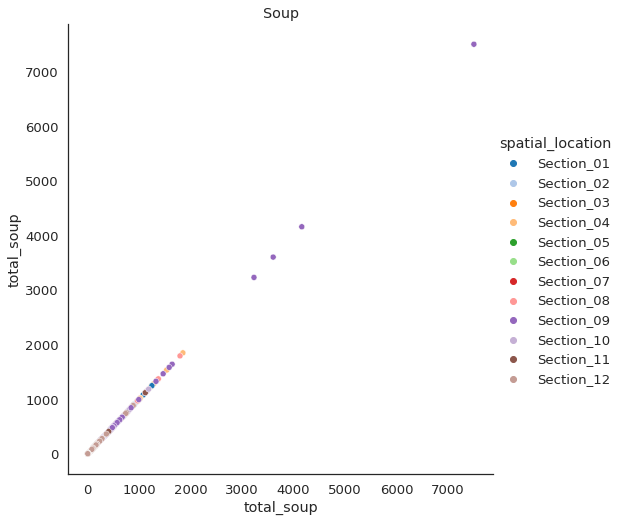

In [ ]:
# Check which sections contain cells with the most soup
sns.set(font_scale = 1.2)
sns.set_style("white")
sns.relplot(data=data.obs, x='total_soup', y='total_soup', hue='spatial_location', height=7, legend="full", palette='tab20')
plt.title('Soup')

Text(0.5, 1.0, 'Soup')

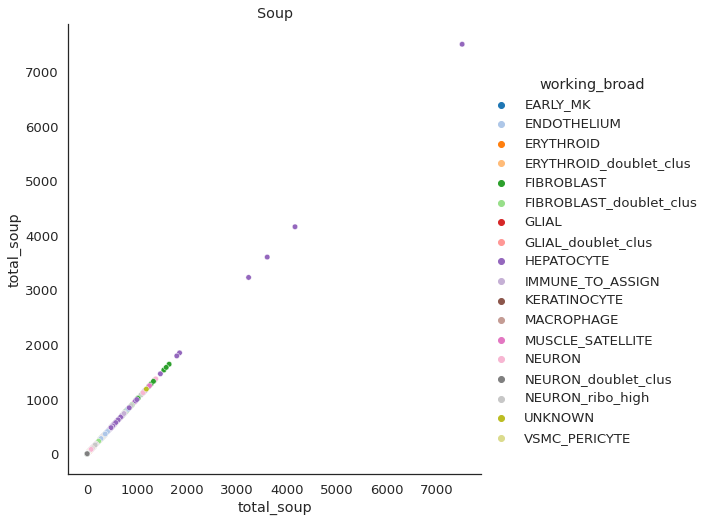

In [ ]:
# Check which celltypes contain most soup
data_plot = data.obs
sns.set(font_scale = 1.2)
sns.set_style("white")
sns.relplot(data=data_plot, x='total_soup', y='total_soup', hue='working_broad', height=7, legend="full", palette='tab20', s=30,)
plt.title('Soup')

### Embryo 3

/home/jovyan/my-conda-envs/Python_env_Hlab/lib/python3.9/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


------------------------------------------------------------------------------------------------------------------------------------------------------ 



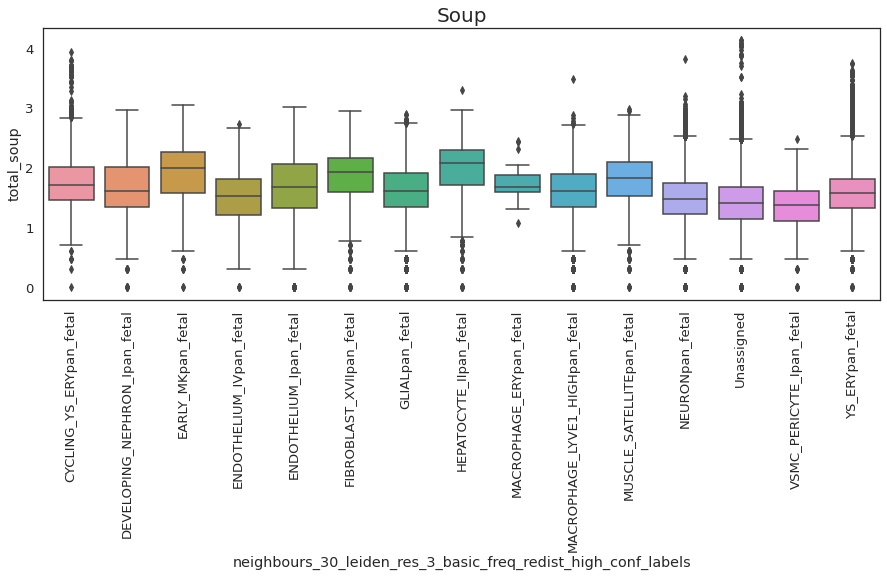

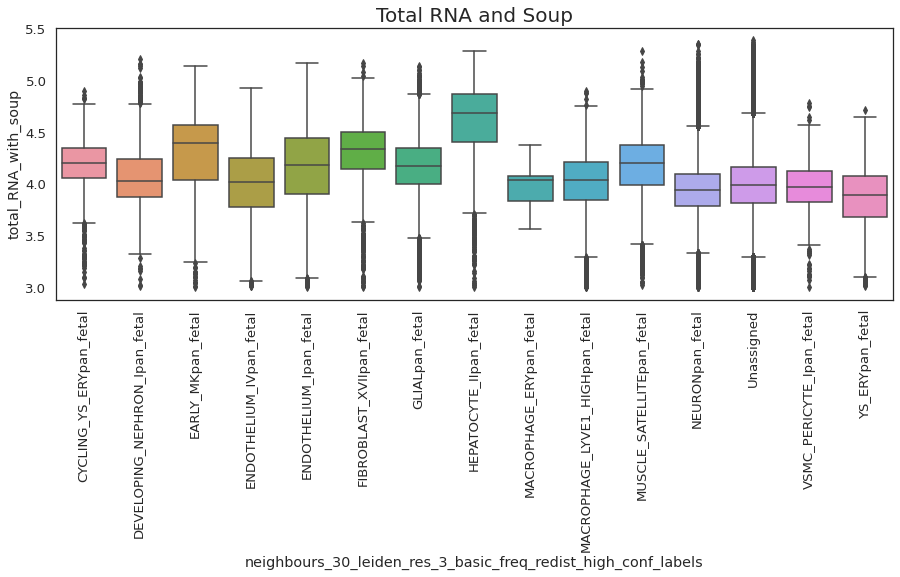


------------------------------------------------------------------------------------------------------------------------------------------------------ 



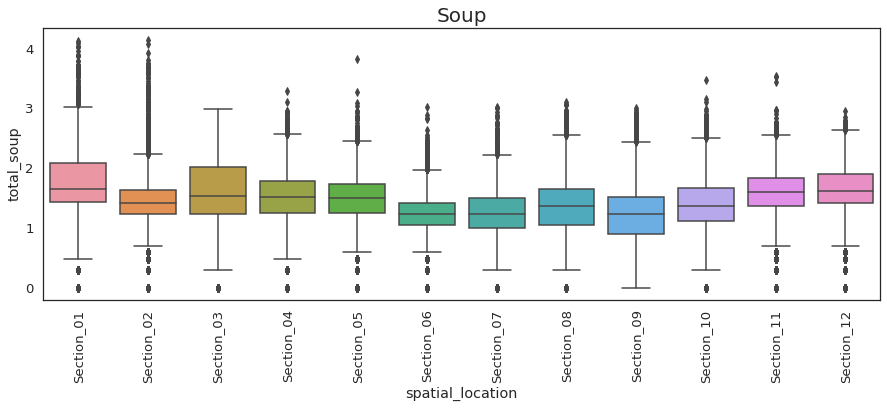

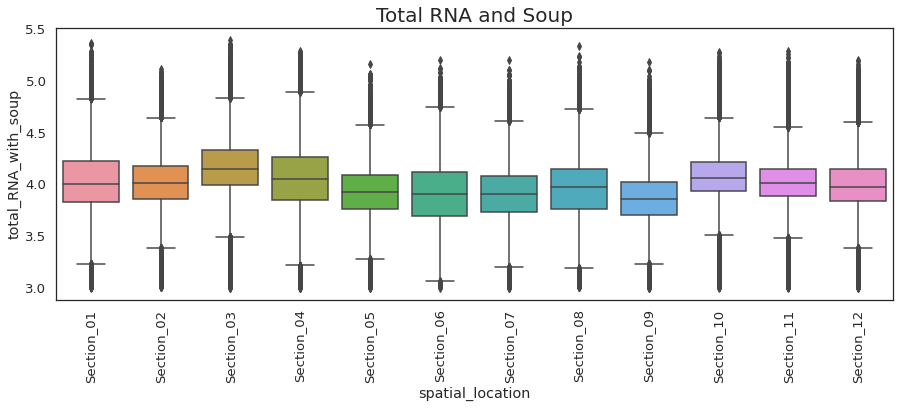


------------------------------------------------------------------------------------------------------------------------------------------------------ 



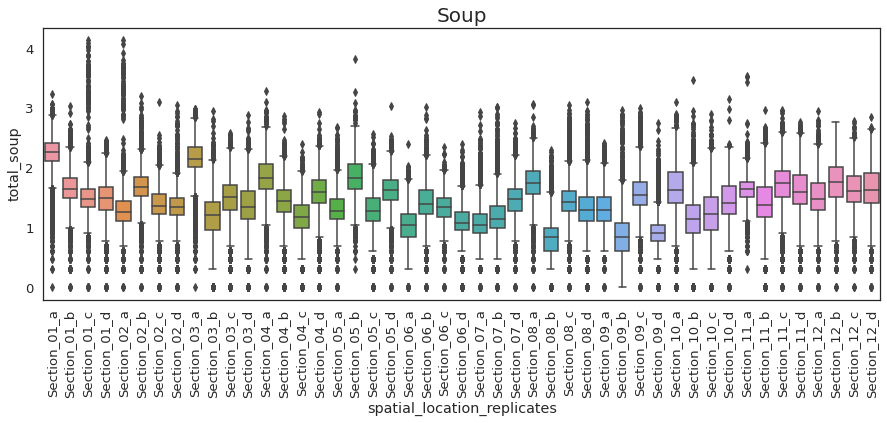

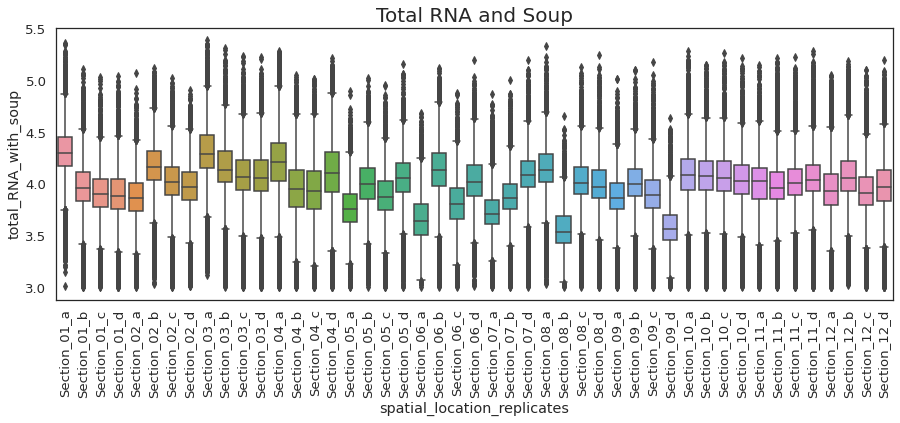


------------------------------------------------------------------------------------------------------------------------------------------------------ 



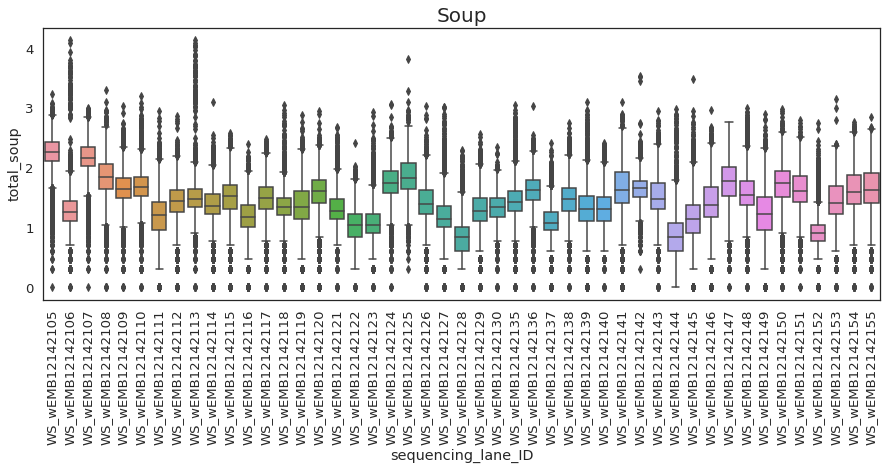

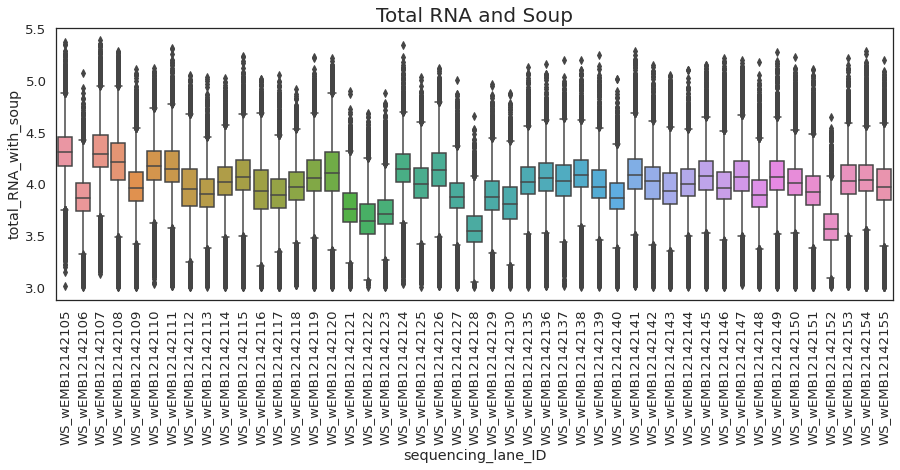

In [ ]:
obs = E3_meta[:]
data = Embryo3
obs = obs[obs.index.isin(list(data.obs.index))]
obs['total_soup'] = np.log10(data.obs['total_soup'][obs.index])
obs['total_RNA_with_soup'] = np.log10(data.obs['total_RNA_with_soup'][obs.index])

meta = E3_meta

print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='neighbours_30_leiden_res_3_basic_freq_redist_high_conf_labels', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='neighbours_30_leiden_res_3_basic_freq_redist_high_conf_labels', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")
print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")
print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location_replicates', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='spatial_location_replicates', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")
print('-'*150,"\n")
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='sequencing_lane_ID', y='total_soup');
plt.xticks (rotation= 90)
plt.title('Soup', fontsize=20)
plt.show();
plt.figure(figsize=(15, 5))
sns.boxplot(data=obs, x='sequencing_lane_ID', y='total_RNA_with_soup');
plt.xticks (rotation= 90)
plt.title('Total RNA and Soup', fontsize=20)
plt.show();
print("")

In [ ]:
gene_data =  pd.DataFrame(data.layers['soup'].todense())
gene_data.index = data.obs.index
gene_data.columns = data.var.index

## Exploration

## Effect on overall data

In [ ]:
sorted_df = gene_data.sum().sort_values(ascending=False)
print('Top 200 genes contributing to soup overall in data:')
sorted_df[:200]

Top 200 genes contributing to soup overall in data:


MT-CO1       2030483.0
MALAT1       1108117.0
MT-CO3       1083810.0
MT-CO2        888617.0
MT-CYB        806840.0
MT-ATP6       793441.0
EEF1A1        645280.0
MTRNR2L12     441659.0
ACTB          364739.0
ACTG1         333178.0
RPL41         301185.0
RPL10         298635.0
RPS8          277760.0
RPLP1         266743.0
MT-ND4L       211612.0
RPL13         203897.0
MT-ND4        203729.0
VIM           196545.0
MT-ND1        190868.0
PTMA          181408.0
RPS12         158511.0
GAPDH         154647.0
RPS3A         146720.0
MT-ND5        136416.0
RPL32         134458.0
RPS4X         117133.0
RPS19         116576.0
RPS23         115202.0
TUBA1A        108125.0
MT-ND3        106935.0
RPL6          105246.0
RPS15A        105172.0
RPS3          103994.0
TMSB10         98884.0
RPS14          98305.0
RPS18          94645.0
RPLP0          93212.0
RPL18A         89427.0
RPS2           88446.0
RPS13          87484.0
RPL28          86339.0
RPS24          85446.0
RPL11          83468.0
RPL7A      

## Effect in column of interest
- e.g. Section
- e.g. Section repliacte

### Section 5 example

In [ ]:
met_sub = meta[meta['spatial_location'].isin(['Section_05'])]
top_20 = (list((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False).index))[0:20]
display(gene_data.loc[gene_data.index.isin(met_sub.index)][top_20])
print("")
print("Top number of genes based off restriction applied:")
display((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False)[:20])

,MT-CO1,MT-CO3,MALAT1,MT-ATP6,MT-CYB,MT-CO2,EEF1A1,MTRNR2L12,ACTB,ACTG1,MT-ND4L,RPL10,MT-ND4,MT-ND1,RPS8,RPLP1,RPL41,MT-ND5,RPL13,PTMA
ACCGTAACATCCAACA-WS_wEMB12142121,18.0,10.0,9.0,8.0,8.0,9.0,5.0,4.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,2.0,2.0,3.0,2.0
TGGTTAGTCAAGATCC-WS_wEMB12142121,3.0,3.0,8.0,1.0,1.0,5.0,4.0,0.0,3.0,3.0,1.0,3.0,1.0,0.0,3.0,2.0,2.0,0.0,2.0,2.0
CTCACACTCTAACGGT-WS_wEMB12142121,15.0,9.0,7.0,7.0,7.0,7.0,4.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
TCTCTAAAGGGTGTGT-WS_wEMB12142121,16.0,9.0,8.0,7.0,8.0,8.0,4.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
GGGCACTTCGGCTACG-WS_wEMB12142121,15.0,8.0,7.0,7.0,7.0,7.0,4.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACAGCTATCACCTCGT-WS_wEMB12142136,2.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
CGAGCCAGTGCACGAA-WS_wEMB12142136,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACTGGTAGAGGTTAT-WS_wEMB12142136,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TGCCCTAAGCACAGGT-WS_wEMB12142136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top number of genes based off restriction applied:


MT-CO1       238532.0
MT-CO3       122718.0
MALAT1       103922.0
MT-ATP6      100311.0
MT-CYB        99679.0
MT-CO2        99283.0
EEF1A1        55309.0
MTRNR2L12     54029.0
ACTB          37311.0
ACTG1         33688.0
MT-ND4L       29590.0
RPL10         28657.0
MT-ND4        26231.0
MT-ND1        24998.0
RPS8          23205.0
RPLP1         20418.0
RPL41         19841.0
MT-ND5        19272.0
RPL13         18523.0
PTMA          16802.0
dtype: float32

### Section 3_b

In [ ]:
met_sub = meta[meta['spatial_location_replicates'].isin(['Section_03_b'])]
top_20 = (list((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False).index))[0:20]
display(gene_data.loc[gene_data.index.isin(met_sub.index)][top_20])
print("")
print("Top number of genes based off restriction applied:")
display((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False)[:20])

,MALAT1,MT-CO1,EEF1A1,MT-CO3,MT-ATP6,MT-CO2,ACTG1,RPL10,ACTB,MT-CYB,RPS8,RPL41,RPLP1,RPL13,RPS3A,RPS12,PTMA,VIM,RPL32,MTRNR2L12
CCTCTGATCAAACGGG-WS_wEMB12142111,10.0,8.0,6.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0
CACCACTTCGTTACAG-WS_wEMB12142111,10.0,8.0,6.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0
ACTATCTGTAATCACC-WS_wEMB12142111,12.0,9.0,7.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0
TCTCATACATTACGAC-WS_wEMB12142111,10.0,7.0,6.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0
AACCATGGTGCTGTAT-WS_wEMB12142111,10.0,8.0,6.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACGCAGCCACGGTTTA-WS_wEMB12142111,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCACTCTGTAGAGCTG-WS_wEMB12142111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TGCGGGTTCAACACCA-WS_wEMB12142111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TAAGAGATCACAATGC-WS_wEMB12142111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top number of genes based off restriction applied:


MALAT1       19278.0
MT-CO1       14128.0
EEF1A1       10836.0
MT-CO3        7146.0
MT-ATP6       6087.0
MT-CO2        5465.0
ACTG1         5459.0
RPL10         4749.0
ACTB          4371.0
MT-CYB        4363.0
RPS8          4232.0
RPL41         3895.0
RPLP1         3220.0
RPL13         3015.0
RPS3A         1919.0
RPS12         1872.0
PTMA          1829.0
VIM           1682.0
RPL32         1641.0
MTRNR2L12     1561.0
dtype: float32

### Celltype: NEURON from working_broad

In [ ]:
met_sub = meta[meta['working_broad'].isin(['NEURON'])]
top_20 = (list((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False).index))[0:20]
display(gene_data.loc[gene_data.index.isin(met_sub.index)][top_20])
print("")
print("Top number of genes based off restriction applied:")
display((gene_data[gene_data.index.isin(met_sub.index)]).sum().sort_values(ascending=False)[:20])

,MT-CO1,MALAT1,MT-CO3,MT-CO2,EEF1A1,MT-CYB,MT-ATP6,ACTB,ACTG1,RPL41,MTRNR2L12,RPL10,RPS8,RPLP1,VIM,RPL13,GAPDH,PTMA,RPS12,RPS3A
CTGGTCTTCCTCCTAG-WS_wEMB12142105,50.0,42.0,34.0,29.0,19.0,26.0,34.0,11.0,12.0,9.0,41.0,9.0,8.0,8.0,6.0,7.0,6.0,8.0,6.0,6.0
TATCAGGTCTATCCCG-WS_wEMB12142105,50.0,39.0,32.0,27.0,17.0,24.0,32.0,10.0,11.0,9.0,39.0,8.0,8.0,7.0,5.0,7.0,6.0,7.0,6.0,6.0
CTGTTTAGTGTTAAGA-WS_wEMB12142105,50.0,39.0,32.0,27.0,17.0,24.0,32.0,10.0,11.0,9.0,39.0,8.0,8.0,7.0,5.0,6.0,6.0,7.0,6.0,6.0
AGCTTGACATGAAGTA-WS_wEMB12142105,50.0,37.0,30.0,26.0,17.0,23.0,30.0,10.0,11.0,8.0,37.0,8.0,8.0,7.0,5.0,6.0,6.0,7.0,5.0,6.0
TTTGTCACAATGTTGC-WS_wEMB12142105,47.0,35.0,28.0,24.0,15.0,21.0,28.0,9.0,10.0,8.0,35.0,7.0,7.0,6.0,5.0,6.0,5.0,7.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATGGGAGTCGGATGTT-WS_wEMB12142155,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,3.0,0.0,1.0,0.0,1.0,0.0,0.0
TGAGCATGTGAAATCA-WS_wEMB12142155,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
CAGCCGACATCGTCGG-WS_wEMB12142155,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
CCTCTGAGTTAAGGGC-WS_wEMB12142155,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Top number of genes based off restriction applied:


MT-CO1       462577.0
MALAT1       310924.0
MT-CO3       241499.0
MT-CO2       201028.0
EEF1A1       195456.0
MT-CYB       175765.0
MT-ATP6      173364.0
ACTB         110050.0
ACTG1        100723.0
RPL41         95543.0
MTRNR2L12     95253.0
RPL10         90135.0
RPS8          85511.0
RPLP1         83827.0
VIM           76431.0
RPL13         61545.0
GAPDH         53045.0
PTMA          52961.0
RPS12         48711.0
RPS3A         46371.0
dtype: float32

# Scatterplots

### Cells containing the most soup

In [ ]:
data.obs[cols] = meta[cols]

Trying to set attribute `.obs` of view, copying.


Text(0.5, 1.0, 'Soup')

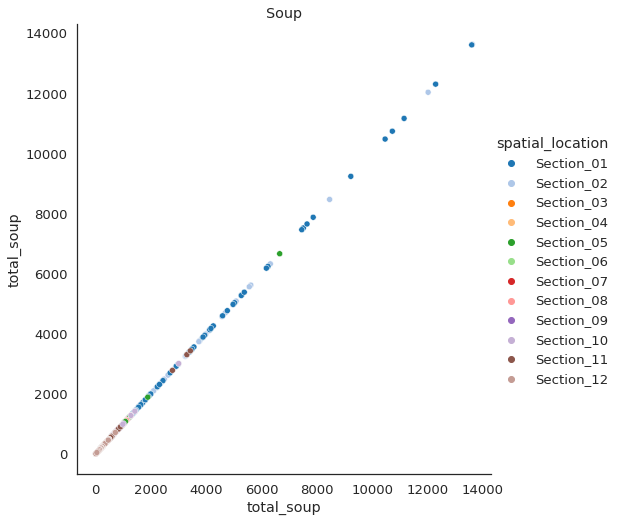

In [ ]:
# Check which sections contain cells with the most soup
sns.set(font_scale = 1.2)
sns.set_style("white")
sns.relplot(data=data.obs, x='total_soup', y='total_soup', hue='spatial_location', height=7, legend="full", palette='tab20')
plt.title('Soup')

Text(0.5, 1.0, 'Soup')

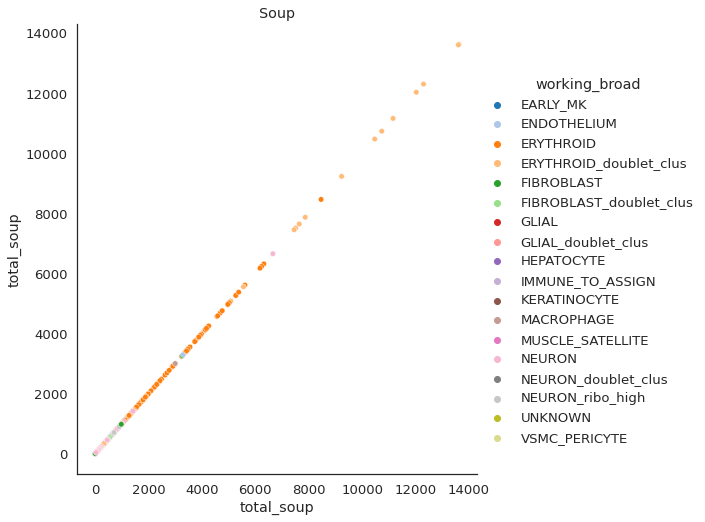

In [ ]:
# Check which celltypes contain most soup
data_plot = data.obs
sns.set(font_scale = 1.2)
sns.set_style("white")
sns.relplot(data=data_plot, x='total_soup', y='total_soup', hue='working_broad', height=7, legend="full", palette='tab20', s=30,)
plt.title('Soup')

# Viualise soup contribution on umap embedding per embryo

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

In [ ]:
e1 = '/nfs/team298/ar32/Whole_embryo/Outputs/Objects/Raw_Objects/F137_all_lanes_raw_counts_20220425.h5ad'
e2 = '/nfs/team298/ar32/Whole_embryo/Outputs/Objects/Raw_Objects/F147_all_lanes_raw_counts_20220425.h5ad'
e3 = '/nfs/team298/ar32/Whole_embryo/Outputs/Objects/Raw_Objects/F158_all_lanes_raw_counts_20220425.h5ad'
metadata_object = sc.read('/nfs/team298/ar32/Whole_embryo/pan_fetal_LR/working_data_2.h5ad')

In [ ]:
E1 = sc.read(e1)
metadata1 = metadata_object[metadata_object.obs.index.isin(list(E1.obs.index))]
E1 = E1[E1.obs.index.isin(list(metadata1.obs.index)),:]

In [ ]:
data = E1
sc.pp.normalize_per_cell(data, counts_per_cell_after=1e4)
sc.pp.log1p(data)
sc.pp.highly_variable_genes(data, subset=False)
sc.pp.pca(data, n_comps=100, use_highly_variable=True, svd_solver='arpack')
sc.pp.neighbors(data, n_neighbors=15, n_pcs=50)
sc.tl.umap(data)

In [ ]:
E1 = data
E1.write('/nfs/team298/ar32/Whole_embryo/random_temp_storage/Embryo1_with_basic_embedding_for_soup_plotting_20220801.h5ad')

In [ ]:
E2 = sc.read(e2)
metadata2 = metadata_object[metadata_object.obs.index.isin(list(E2.obs.index))]
E2 = E2[E2.obs.index.isin(list(metadata2.obs.index)),:]

In [ ]:
data = E2
sc.pp.normalize_per_cell(data, counts_per_cell_after=1e4)
sc.pp.log1p(data)
sc.pp.highly_variable_genes(data, subset=False)
sc.pp.pca(data, n_comps=100, use_highly_variable=True, svd_solver='arpack')
sc.pp.neighbors(data, n_neighbors=15, n_pcs=50)
sc.tl.umap(data)

In [ ]:
E2 = data
E2.write('/nfs/team298/ar32/Whole_embryo/random_temp_storage/Embryo2_with_basic_embedding_for_soup_plotting_20220801.h5ad')

In [ ]:
E3 = sc.read(e3)
metadata3 = metadata_object[metadata_object.obs.index.isin(list(E3.obs.index))]
E3 = E3[E3.obs.index.isin(list(metadata3.obs.index)),:]

In [ ]:
data = E3
sc.pp.normalize_per_cell(data, counts_per_cell_after=1e4)
sc.pp.log1p(data)
sc.pp.highly_variable_genes(data, subset=False)
sc.pp.pca(data, n_comps=100, use_highly_variable=True, svd_solver='arpack')
sc.pp.neighbors(data, n_neighbors=15, n_pcs=50)
sc.tl.umap(data)

In [ ]:
E3 = data
E3.write('/nfs/team298/ar32/Whole_embryo/random_temp_storage/Embryo3_with_basic_embedding_for_soup_plotting_20220801.h5ad')

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc

In [ ]:
e1 = '/nfs/team298/ar32/Whole_embryo/random_temp_storage/Embryo1_with_basic_embedding_for_soup_plotting_20220801.h5ad'
e2 = '/nfs/team298/ar32/Whole_embryo/random_temp_storage/Embryo2_with_basic_embedding_for_soup_plotting_20220801.h5ad'
e3 = '/nfs/team298/ar32/Whole_embryo/random_temp_storage/Embryo3_with_basic_embedding_for_soup_plotting_20220801.h5ad'

E1 = sc.read(e1)
E2 = sc.read(e2)
E3 = sc.read(e3)

In [ ]:
genes_E1 = [
'EEF1A1',
'MT-CO1',
'RPL41',
'ACTB',
'MT-CO2',
'MT-CO3',
'RPLP1',
'RPL10',
'MALAT1',
'ACTG1',
'RPS8',
'GAPDH',
'VIM',
'RPL13',
'HBZ',
'RPS12',
'HBE1',
'RPL32',
'RPLP0',
'RPS23',
'RPS3',
'RPS15A',
'MT-ND4L',
'FTL',
'MT-CYB',
'RPS3A',
'RPL7A',
'RPS4X',
'SERPINA1',
'RPS14',
'APOA2',
'RPS19',
'RPL18A',
'RPL30',
'RPS13',
'RPL28',
'APOA1',
'PTMA',
'AFP',
'TMSB10',
'HIST1H4C',
'RPL29',
'RPS24',
'RPS18',
'RPL11',
'TUBB',
'RPL19',
'HBG2',
'RPL6',
'TUBB3',
'RPL39',
'MT-ATP6',
'RPS27A',
'RPL34',
'RPS15',
'RPL26',
'TUBA1A',
'RPL37',
'HSP90AA1',
'RPL18',
'RPL8',
'ALB',
'FTH1',
'RPL15',
'CKB',
'MT-ND3',
'MTRNR2L12',
'RPL5',
'RPS7',
'RPS27',
'RPL12',
'MT1E',
'RPS6',
'TUBB2B',
'RPL35A',
'TPT1',
'RPL3',
'MT2A',
'CRABP1',
'ACTC1',
'RPS28',
'AHSG',
'TUBA1B',
'STMN1',
'TTR',
'HNRNPA1',
'STMN2',
'TMSB4X',
'HBA1',
'MT1G',
'H3F3A',
'RACK1',
'MT-ND4',
'RPS5',
'HBA2',
'HBG1',
'RPL17',
'APOC1',
'SPP1',
'MT1H',
'C1orf61',
'MT-ND1',
'TTYH1',
'RBP4',
'MYL7',
'NEFM',
'RPL24',
'MYL4',
'PPIA',
'RPSA',
'RPL14',
'LGALS1',
'TPM1',
'UBE2C',
'NACA',
'SST',
'RPL10A',
'RPS25',
'NEFL',
'TF',
'RPS26',
'CLDN5',
'PCOLCE',
'RAMP2',
'MT-ATP8',
'HSPA1A',
'FABP1',
'MPZ',
'MT1F',
'DLK1',
'HMGB1',
'AHSP',
'APOM',
'LUM',
'GAP43',
'EGFL8',
'HSP90AB1',
'RPS9',
'MT1X',
'AMBP',
'RPL9',
'HBM',
'S100B',
'MDK',
'IGF2',
'SNCG',
'RPL37A',
'RTN1',
'APOC3',
'FGB',
'RPLP2',
'RPL21',
'RNASE1',
'MIF',
'NPPA',
'SPINK1',
'PRPH',
'S100A11',
'TOP2A',
'HPGD',
'PCP4',
'CAV1',
'JUN',
'RPL23A',
'APOC2',
'TTN',
'EDNRB',
'CCN1',
'MT1M',
'FOS',
'ITM2A',
'APOE',
'CD68',
'MYLPF',
'ZFP36',
'RPL22',
'CD14',
'SOX7',
'PLP1',
'RPL36A',
'VTN',
'CCNB1',
'S100A16',
'COL1A2',
'CCK',
'TAGLN3',
'HIST1H1A',
'CXCL14',
'KRT8',
'KRT19',
'MYL3',
'SLC38A5',
'ZFP36L1',
'PLVAP',
'H3F3B',
'HES6',
'TNNC1',
'ENO2',
'RPL36',
'ASS1',
]

genes_E2 = [
'MT-CO1',
'MTRNR2L12',
'MT-CO3',
'EEF1A1',
'MT-ATP6',
'MT-CO2',
'MT-CYB',
'ACTB',
'RPL41',
'RPLP1',
'MALAT1',
'ACTG1',
'RPL10',
'RPS8',
'RPL13',
'RPS12',
'RPL32',
'RPS3A',
'RPS18',
'RPS23',
'RPS19',
'GAPDH',
'MT-ND4L',
'RPS14',
'RPLP0',
'RPL18A',
'MT-ND4',
'RPS15A',
'VIM',
'RPL28',
'PTMA',
'RPL7A',
'RPS3',
'TPT1',
'RPL30',
'RPS13',
'RPL11',
'RPL19',
'RPS24',
'MT-ND1',
'RPS2',
'MT-ND5',
'RPL6',
'RPL3',
'RPL26',
'RPS15',
'RPL29',
'RPS27A',
'RPS7',
'TMSB10',
'FTL',
'RPL34',
'RPL8',
'RPL18',
'RPS6',
'RPL37',
'FTH1',
'RPL39',
'RPL15',
'HBZ',
'RPS4X',
'RPL5',
'RPL17',
'HNRNPA1',
'RPL12',
'TUBB',
'RPS28',
'RPL35A',
'RPL14',
'RPS5',
'RPS27',
'HSP90AB1',
'HSP90AA1',
'SERPINA1',
'AFP',
'HIST1H4C',
'RPL10A',
'HBE1',
'TUBA1A',
'RPL21',
'MT-ND3',
'MT-ATP8',
'RPL24',
'TUBA1B',
'APOA2',
'RACK1',
'H3F3A',
'TUBB3',
'MDK',
'NACA',
'IGF2',
'RPS25',
'MT-ND2',
'RPS9',
'HBG2',
'ALB',
'FOS',
'APOA1',
'RPL13A',
'HMGB1',
'STMN1',
'RPLP2',
'CKB',
'NPM1',
'TMSB4X',
'MIF',
'RPSA',
'H3F3B',
'HIST1H1B',
'ACTC1',
'RPL23A',
'CRABP1',
'RPS16',
'H19',
'NEFM',
'EEF2',
'PPIA',
'STMN2',
'NEFL',
'RPL36',
'RPL37A',
'RPL4',
'HIST1H3D',
'JUN',
'GNAS',
'RPL9',
'HIST1H3B',
'MARCKSL1',
'TUBB2B',
'RPL36A',
'HIST1H2AL',
'HNRNPA2B1',
'MT2A',
'RPL35',
'HIST1H1A',
'MYL7',
'TTR',
'HBG1',
'MT-ND6',
'TPM1',
'HIST1H2AG',
'FAU',
'HIST1H1C',
'APOB',
'HMOX1',
'MT1F',
'RPS21',
'AHSG',
'UBE2C',
'TTYH1',
'RPL22',
'MT1E',
'SPP1',
'COL3A1',
'C1orf61',
'TNNI1',
'GAP43',
'CLDN5',
'TTN',
'HSPA1A',
'HIST1H3G',
'HIST1H2AH',
'EEF1G',
'MT1G',
'RBP4',
'TOP2A',
'HIST1H1D',
'HES6',
'LGALS1',
'HES5',
'MPZ',
'FABP1',
'APOM',
'CCN1',
'HIST1H3F',
'APOC1',
'MYLPF',
'RNASE1',
'RTN1',
'TNNC1',
'SST',
'DLL1',
'YBX1',
'FGB',
'CFL1',
'INA',
'TF',
'PCOLCE',
'MT1X',
'CENPF',
'EGR1',
'HBA2',
'G0S2',
'HBA1',
'HIST1H2BF',
'HIST1H2BB',
'GPC3',
'PLP1',
'MYL3',
'TAGLN3',
]

genes_E3 = [
'MT-CO1',
'MALAT1',
'MT-CO3',
'MT-CO2',
'MT-CYB',
'MT-ATP6',
'EEF1A1',
'MTRNR2L12',
'ACTB',
'ACTG1',
'RPL41',
'RPL10',
'RPS8',
'RPLP1',
'MT-ND4L',
'RPL13',
'MT-ND4',
'VIM',
'MT-ND1',
'PTMA',
'RPS12',
'GAPDH',
'RPS3A',
'MT-ND5',
'RPL32',
'RPS4X',
'RPS19',
'RPS23',
'TUBA1A',
'MT-ND3',
'RPL6',
'RPS15A',
'RPS3',
'TMSB10',
'RPS14',
'RPS18',
'RPLP0',
'RPL18A',
'RPS2',
'RPS13',
'RPL28',
'RPS24',
'RPL11',
'RPL7A',
'RPL30',
'TUBB',
'MT-ATP8',
'FTH1',
'RPL34',
'HIST1H4C',
'RPS27A',
'FTL',
'RPL19',
'RPS15',
'STMN1',
'TPT1',
'RPL39',
'RPS7',
'RPL29',
'TUBB3',
'MT-ND2',
'RPL37',
'RPL26',
'RPL8',
'RPL3',
'RPS6',
'RPL18',
'RPL5',
'TUBA1B',
'HNRNPA1',
'H3F3A',
'CRABP1',
'TMSB4X',
'RPS28',
'RPS27',
'JUN',
'RPL35A',
'HMGB1',
'RPL12',
'RPL15',
'HBZ',
'RPL14',
'RPL17',
'CKB',
'RACK1',
'STMN2',
'SERPINA1',
'RPS5',
'AFP',
'MDK',
'HBE1',
'NEFL',
'H3F3B',
'RPL24',
'NEFM',
'HSP90AB1',
'NACA',
'HNRNPA2B1',
'RPL21',
'GNAS',
'HSP90AA1',
'APOA2',
'TUBB2B',
'MARCKSL1',
'IGF2',
'ALB',
'HBG2',
'RPL10A',
'RPLP2',
'RPL37A',
'APOA1',
'HIST1H1B',
'RPSA',
'MAP1B',
'NPM1',
'RPS9',
'RPS25',
'H19',
'FOS',
'ACTC1',
'MIF',
'MT1F',
'RPL13A',
'EEF2',
'GAP43',
'HMGB2',
'PPIA',
'CENPF',
'RPS21',
'HIST1H1A',
'RPL36',
'TTYH1',
'RPL36A',
'RPL35',
'HIST1H1D',
'TAGLN3',
'MT-ND6',
'RPL9',
'HES6',
'RPL22',
'MT1G',
'RTN1',
'SPP1',
'AHSG',
'HIST1H3D',
'CRMP1',
'RPL4',
'EEF1G',
'HMGN2',
'UBE2C',
'H2AFZ',
'TOP2A',
'HIST1H1C',
'UBB',
'INA',
'PRDX2',
'CFL1',
'FAU',
'TTN',
'PCOLCE',
'COL3A1',
'LGALS1',
'RPL23A',
'TPM1',
'COL1A2',
'C1orf61',
'HIST1H3B',
'FGFBP3',
'YBX1',
'GNG3',
'TNNI1',
'CCNB1',
'MYL7',
'KIF5C',
'MKI67',
'MYL6',
'APOB',
'IGFBP5',
'MPZ',
'SFRP1',
'PTTG1',
'CCN1',
'HES5',
'RAMP2',
'S100A11',
'TPX2',
'CCN2',
'CALM2',
'GPC3',
'PLP1',
'HIST1H2AG',
'RPS16',
'DLK1',
'MARCKS',
'APOC1',
'GDAP1L1',
'S100B',
'TTR',
'TPM2',
'KRT18',
]

### Embryo F137 top 200 genes on basic umap

In [ ]:
sc.pl.umap(E1, color=genes_E1)

### Embryo F147 top 200 genes on basic umap

In [ ]:
sc.pl.umap(E2, color=genes_E2)

### Embryo F158 top 200 genes on basic umap

In [ ]:
sc.pl.umap(E3, color=genes_E3)

***
### Dependencies
Here are some information about resources and import package versions used within this script

In [1]:
%load_ext watermark
%watermark -v -m -p numpy,pandas,scanpy,anndata

Python implementation: CPython
Python version       : 3.9.4
IPython version      : 7.24.1

numpy  : 1.20.3
pandas : 1.2.4
scanpy : 1.7.2
anndata: 0.7.6

Compiler    : GCC 9.3.0
OS          : Linux
Release     : 4.15.0-112-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 26
Architecture: 64bit

